# Лабораторная работа E9 — Не «какой жест», а «насколько сильно»

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/biomenace/digital-signal-processing/blob/main/notebooks/e9.ipynb)

Ноутбук-спутник к интерактивной работе: **[открыть саму лабораторную](https://biomenace.github.io/digital-signal-processing/labs/e9.html)**.

**Что разбираем.** До сих пор мы отвечали на вопрос «какой жест» — это
классификация. Но протезу мало знать, что кисть сжимается: ему нужно, с
какой силой. Ответ здесь — не номер класса, а число от 0 до 100 %, и задача
из классификации превращается в **регрессию**.

**Честно о данных.** В датасете UCI силы сжатия нет — тензодатчика при записи
не было. Поэтому целью берём **учебный заменитель силы**: нормированную
RMS-огибающую сигнала. Это законно как упражнение (пайплайн ровно тот же), но
нельзя выдавать за измеренную силу: мы учим модель предсказывать величину,
которую сами же посчитали из того же сигнала. На датасетах с настоящим
датчиком силы меняется только источник цели.

Регрессию берём линейную с регуляризацией — `Ridge`. Признаков 56, окон
несколько сотен, и без штрафа за большие коэффициенты модель начнёт
подстраиваться под шум.

In [1]:
# ЯЧЕЙКА 1 · Установка и импорты.
# Запусти один раз в начале работы и больше сюда не возвращайся.
# В Google Colab почти всё уже стоит, поэтому обычно ничего не скачивается.

import importlib.util
import subprocess
import sys


def ensure(packages):
    """Ставит только те пакеты, которых нет. packages: [(модуль, имя-для-pip)]."""
    missing = [pip for mod, pip in packages if not importlib.util.find_spec(mod)]
    if missing:
        print("Ставлю:", ", ".join(missing))
        subprocess.run([sys.executable, "-m", "pip", "install", "-q", *missing],
                       check=True)
    print("Готово. Python", sys.version.split()[0])


ensure([("numpy", "numpy"), ("scipy", "scipy"), ("matplotlib", "matplotlib")])

import numpy as np
import matplotlib
import matplotlib.pyplot as plt

%matplotlib inline
matplotlib.rcParams.update({
    "figure.figsize": (11, 4.5),
    "figure.dpi": 110,
    "axes.grid": True,
    "grid.linewidth": 0.4,
    "axes.titlesize": 12,
    "font.size": 11,
})

Готово. Python 3.10.12


In [2]:
ensure([("sklearn", "scikit-learn")])

from sklearn.linear_model import Ridge
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import make_pipeline

Готово. Python 3.10.12


In [3]:
# ЯЧЕЙКА 2 · Признаки ЭМГ и нарезка на окна.
# Это «чёрный ящик» лабы: запусти один раз и дальше просто вызывай функции.
# Внутри — классический набор Хадгинса (Hudgins et al., 1993) плюс две
# частотные характеристики. Разбираться в реализации не нужно.

FS = 1000.0          # частота дискретизации записи, Гц
N_CH = 8             # каналов в браслете

TD_NAMES = ["MAV", "RMS", "WL", "ZC", "SSC"]
FREQ_NAMES = ["MDF", "MNF"]


def window_signal(X, y, fs=FS, win_ms=200.0, step_ms=100.0, keep=None, purity=0.6):
    """Режет запись X[N, C] с метками y[N] на скользящие окна.

    Метка окна — самый частый класс внутри него. Окно на стыке двух жестов
    (ни один класс не занимает purity доли окна) выбрасывается.
    Возвращает (windows[K, W, C], labels[K]).
    """
    width = int(round(win_ms / 1000.0 * fs))
    step = int(round(step_ms / 1000.0 * fs))
    keep = set(range(1, 8)) if keep is None else set(keep)
    wins, labs = [], []
    for start in range(0, len(X) - width + 1, step):
        chunk = y[start:start + width]
        values, counts = np.unique(chunk, return_counts=True)
        label = int(values[np.argmax(counts)])
        if label not in keep or counts.max() < purity * width:
            continue
        wins.append(X[start:start + width, :])
        labs.append(label)
    if not wins:
        return np.empty((0, width, X.shape[1])), np.empty((0,), int)
    return np.asarray(wins), np.asarray(labs, int)


def td_features(x, rel_eps=0.02):
    """Пять признаков Хадгинса по одному каналу.

    MAV — средний модуль (насколько сильно напряжена мышца);
    RMS — эффективная амплитуда (то же, что в лабе E4);
    WL  — суммарная длина кривой, мера «изрезанности»;
    ZC  — сколько раз сигнал пересёк ноль (грубая оценка частоты);
    SSC — сколько раз сменился знак наклона (тоже про частоту).

    ZC и SSC считают с мёртвой зоной rel_eps от уровня сигнала: без неё они
    считали бы дрожание нуля, а не настоящие колебания.
    """
    eps = rel_eps * np.sqrt(np.mean(x ** 2)) + 1e-12
    diff = np.diff(x)
    zc = int(np.sum((x[:-1] * x[1:] < 0) & (np.abs(diff) > eps)))
    d1, d2 = x[1:-1] - x[:-2], x[1:-1] - x[2:]
    ssc = int(np.sum((d1 * d2 > 0) & ((np.abs(d1) > eps) | (np.abs(d2) > eps))))
    return np.array([np.mean(np.abs(x)), np.sqrt(np.mean(x ** 2)),
                     np.sum(np.abs(diff)), zc, ssc], float)


def freq_features(x, fs=FS):
    """MDF и MNF — медианная и средняя частоты спектра мощности канала.

    MDF делит энергию спектра пополам, MNF — центр масс спектра. Обе падают
    при утомлении мышцы, поэтому их считают вместе с амплитудными.
    """
    x = x - np.mean(x)
    power = np.abs(np.fft.rfft(x * np.hanning(len(x)))) ** 2
    freqs = np.fft.rfftfreq(len(x), d=1.0 / fs)
    total = power.sum() + 1e-24
    cumulative = np.cumsum(power)
    mdf = freqs[np.searchsorted(cumulative, cumulative[-1] / 2)]
    return np.array([mdf, np.sum(freqs * power) / total], float)


def features_window(win, fs=FS):
    """Одно окно win[W, C] → один длинный вектор чисел: 7 признаков на канал."""
    return np.concatenate([
        np.concatenate([td_features(win[:, c]), freq_features(win[:, c], fs)])
        for c in range(win.shape[1])])


def feature_names(n_ch=N_CH):
    """Имена координат вектора признаков — в том же порядке, что и значения."""
    return ["ch%d_%s" % (c + 1, nm)
            for c in range(n_ch) for nm in TD_NAMES + FREQ_NAMES]


def features_of(X, y, fs=FS, win_ms=200.0, step_ms=100.0, keep=None):
    """Запись → матрица признаков. Возвращает (Xf[K, D], labels[K])."""
    wins, labs = window_signal(X, y, fs, win_ms, step_ms, keep)
    return np.array([features_window(w, fs) for w in wins]), labs

In [4]:
# ЯЧЕЙКА 3 · Данные: скачиваем настоящий датасет.
# Работаем не на выдумке, а на открытой записи UCI «EMG Data for Gestures»
# (Lobov et al., 2018): 36 человек, браслет MYO — восемь электродов по
# окружности предплечья, по две серии на человека, размеченные жесты.
# Архив ~17 МБ, качается один раз за сессию. Ничего ставить руками не нужно.

import os
import glob
import urllib.request
import zipfile

DATA_URL = "https://archive.ics.uci.edu/static/public/481/emg+data+for+gestures.zip"
DATA_DIR = "EMG_data_for_gestures-master"

GESTURE_NAMES = {
    0: "неразмечено", 1: "покой", 2: "кулак", 3: "сгибание",
    4: "разгибание", 5: "радиальное", 6: "локтевое", 7: "ладонь",
}


def fetch_dataset(url=DATA_URL, directory=DATA_DIR):
    """Скачивает и распаковывает датасет. Повторный вызов ничего не делает."""
    # Печатаем только имя папки, без полного пути: путь на чужой машине
    # читателю ничего не говорит, а в сохранённом выводе ноутбука остаётся.
    directory = os.environ.get("EMG_DATA_DIR", directory)
    name = os.path.basename(directory.rstrip("/\\")) or directory
    if os.path.isdir(directory):
        print("Датасет уже на месте:", name)
        return directory
    print("Скачиваю архив (~17 МБ)...")
    archive, _ = urllib.request.urlretrieve(url)
    with zipfile.ZipFile(archive) as zf:
        zf.extractall(".")
    os.remove(archive)
    print("Готово:", name)
    return directory


def list_subjects(directory=DATA_DIR):
    """Номера доступных испытуемых: '01', '02', ... '36'."""
    return sorted(d for d in os.listdir(directory)
                  if d.isdigit() and os.path.isdir(os.path.join(directory, d)))


def subject_files(subject, directory=DATA_DIR):
    """Файлы одного человека — обычно две серии, записанные подряд."""
    pattern = os.path.join(directory, str(subject).zfill(2), "*_raw_data_*.txt")
    return sorted(glob.glob(pattern))


def load_record(path):
    """Один файл записи → (X[N, 8], y[N]).

    В файле десять столбцов: время в мс, восемь каналов и метка жеста.
    Шаг времени 1 мс, отсюда FS = 1000 Гц. Метка 0 — участок без разметки.
    Каналы переводим из вольт в милливольты, иначе все числа выглядят как
    0.00002 и читать их невозможно.
    """
    data = np.loadtxt(path, skiprows=1)
    return data[:, 1:9] * 1000.0, data[:, 9].astype(int)


def plot_record(X, y, fs=FS, seconds=12.0, channels=(0, 2, 4, 6)):
    """Кусок записи: как выглядят каналы и где какой жест был размечен."""
    n = min(len(X), int(seconds * fs))
    t = np.arange(n) / fs
    present = sorted(set(int(v) for v in np.unique(y[:n])))
    fig, axes = plt.subplots(len(channels) + 1, 1, sharex=True,
                             figsize=(12, 1.4 * len(channels) + 2.4))
    for ax, c in zip(axes, channels):
        ax.plot(t, X[:n, c], lw=0.6, color="steelblue")
        ax.set_ylabel("кан. %d" % (c + 1))
    axes[-1].step(t, y[:n], where="post", color="darkorange", lw=1.6)
    axes[-1].set(xlabel="$t$, с", ylabel="жест", yticks=present)
    axes[-1].set_yticklabels([GESTURE_NAMES[v] for v in present])
    axes[0].set_title("Запись браслета MYO: четыре канала из восьми и разметка жестов")
    fig.tight_layout()
    plt.show()


def class_table(y, title="Распределение по классам"):
    """Сколько окон (или отсчётов) пришлось на каждый класс."""
    values, counts = np.unique(y, return_counts=True)
    print(title + ":")
    for v, c in zip(values, counts):
        print("   %-12s %6d" % (GESTURE_NAMES[int(v)], c))

## Ячейка 4 · Окна, признаки и цель

Уровень усилия окна считаем как среднюю по каналам RMS, а затем растягиваем
шкалу так, чтобы 2-й процентиль стал нулём, а 98-й — сотней. Крайние
процентили вместо минимума и максимума — чтобы один случайный всплеск не
сдвинул всю шкалу.

In [5]:
WIN_MS = 200.0
STEP_MS = 50.0
GESTURES = [1, 2, 3, 4, 5, 6, 7]     # все размеченные: нужен разброс усилия

root = fetch_dataset()
X, y = load_record(subject_files("01", root)[0])

windows, labels = window_signal(X, y, FS, WIN_MS, STEP_MS, keep=GESTURES)
Xf = np.array([features_window(w, FS) for w in windows])

raw = np.array([np.mean(np.sqrt(np.mean(w ** 2, axis=0))) for w in windows])
low, high = np.percentile(raw, 2), np.percentile(raw, 98)
level = np.clip((raw - low) / (high - low + 1e-12), 0, 1) * 100.0

print("Окон: %d, признаков в окне: %d" % (len(level), Xf.shape[1]))
print("Уровень усилия: медиана %.1f %%, разброс %.1f–%.1f %%"
      % (np.median(level), level.min(), level.max()))

Датасет уже на месте: EMG_data_for_gestures-master


Окон: 428, признаков в окне: 56
Уровень усилия: медиана 57.6 %, разброс 0.0–100.0 %


## Ячейка 5 · Как уровень усилия идёт вдоль записи

Полезно один раз посмотреть на цель глазами: видно чередование «напряжение —
пауза», и видно, что у разных жестов типичный уровень разный.

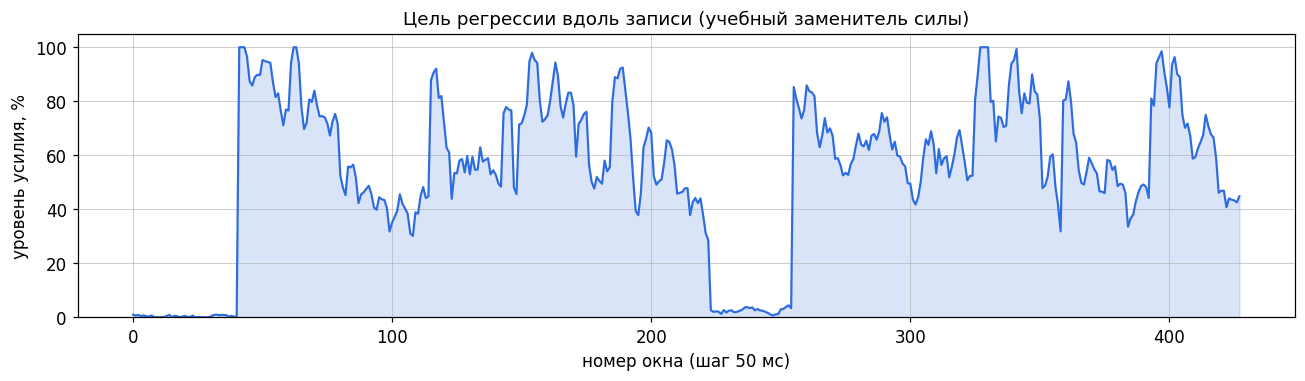

покой        средний уровень   1.3 %  (окон 73)
кулак        средний уровень  76.9 %  (окон 69)
сгибание     средний уровень  52.4 %  (окон 75)
разгибание   средний уровень  69.2 %  (окон 68)
радиальное   средний уровень  63.9 %  (окон 70)
локтевое     средний уровень  62.6 %  (окон 73)


In [6]:
# По оси X — номер окна, а не время: неразмеченные паузы мы выбросили, и
# соседние окна на графике не всегда соседние в записи.
index = np.arange(len(level))

fig, ax = plt.subplots(figsize=(12, 3.6))
ax.plot(index, level, lw=1.4, color="#2d6cdf")
ax.fill_between(index, 0, level, alpha=0.18, color="#2d6cdf")
ax.set(xlabel="номер окна (шаг %.0f мс)" % STEP_MS,
       ylabel="уровень усилия, %", ylim=(0, 105),
       title="Цель регрессии вдоль записи (учебный заменитель силы)")
fig.tight_layout()
plt.show()

for gesture in GESTURES:
    mask = labels == gesture
    if mask.any():
        print("%-12s средний уровень %5.1f %%  (окон %d)"
              % (GESTURE_NAMES[gesture], level[mask].mean(), int(mask.sum())))

## Ячейка 6 · Первый заход — и ловушка, в которую он попадает

Обучим `Ridge` предсказывать уровень **того же окна**, из которого взяты
признаки. Делим окна случайно: 70 % на обучение, 30 % на проверку.

In [7]:
ALPHA = 1.0                          # сила регуляризации Ridge


def r_squared(true, predicted):
    """Доля разброса цели, которую модель объяснила. 1 — идеал, 0 — уровень среднего."""
    return 1.0 - (np.sum((true - predicted) ** 2)
                  / np.sum((true - np.mean(true)) ** 2))


order = np.random.default_rng(0).permutation(len(level))
split = int(0.7 * len(order))
train, test = order[:split], order[split:]

model = make_pipeline(StandardScaler(), Ridge(alpha=ALPHA))
model.fit(Xf[train], level[train])
predicted = model.predict(Xf[test])

print("R² = %.3f, средняя ошибка = %.1f %% усилия"
      % (r_squared(level[test], predicted),
         np.mean(np.abs(predicted - level[test]))))

R² = 0.999, средняя ошибка = 0.6 % усилия


Почти единица — и радоваться тут нечему. Мы сами посчитали цель как среднюю
по каналам RMS, а RMS каждого канала лежит прямо в векторе признаков. Модели
достаточно сложить восемь чисел и поделить на восемь; ничему полезному она
не научилась. Такой результат — верный признак **утечки цели в признаки**, и
первое, что стоит проверять, когда R² подозрительно высок.

## Ячейка 7 · Задача, в которой ответа в признаках нет

Протезу нужен не текущий уровень (он и так известен), а тот, который будет
через долю секунды — иначе кисть всегда опаздывает. Сдвинем цель на
`HORIZON` миллисекунд вперёд: признаки берём из окна сейчас, предсказываем
уровень будущего окна.

Сравнивать будем не с нулём, а с честным соперником — правилом «уровень не
изменится». Модель имеет смысл только если она это правило обыгрывает.

In [8]:
HORIZON = 500.0                      # на сколько миллисекунд смотрим вперёд
lag = int(round(HORIZON / STEP_MS))

Xnow, future = Xf[:-lag], level[lag:]
persistence = level[:-lag]           # соперник: «будет как сейчас»

order = np.random.default_rng(0).permutation(len(future))
split = int(0.7 * len(order))
train, test = order[:split], order[split:]

model = make_pipeline(StandardScaler(), Ridge(alpha=ALPHA))
model.fit(Xnow[train], future[train])
predicted = model.predict(Xnow[test])

true = future[test]
r2 = r_squared(true, predicted)
mae = np.mean(np.abs(predicted - true))

print("Горизонт %.0f мс (%d шагов окна вперёд)" % (HORIZON, lag))
print("Модель:              R² = %6.3f, средняя ошибка = %5.1f %%" % (r2, mae))
print("«Будет как сейчас»:  R² = %6.3f, средняя ошибка = %5.1f %%"
      % (r_squared(true, persistence[test]),
         np.mean(np.abs(persistence[test] - true))))

print("\nОшибка модели по зонам уровня:")
for low_edge, high_edge in [(0, 20), (20, 40), (40, 60), (60, 80), (80, 101)]:
    mask = (true >= low_edge) & (true < high_edge)
    if mask.any():
        print("   %3d–%3d %%: окон %3d, средняя ошибка %5.1f %%"
              % (low_edge, min(high_edge, 100), int(mask.sum()),
                 np.mean(np.abs(predicted[mask] - true[mask]))))

Горизонт 500 мс (10 шагов окна вперёд)
Модель:              R² =  0.457, средняя ошибка =  16.5 %
«Будет как сейчас»:  R² =  0.210, средняя ошибка =  17.1 %

Ошибка модели по зонам уровня:
     0– 20 %: окон  19, средняя ошибка  20.9 %
    20– 40 %: окон   5, средняя ошибка  18.7 %
    40– 60 %: окон  42, средняя ошибка  12.7 %
    60– 80 %: окон  36, средняя ошибка  12.3 %
    80–100 %: окон  24, средняя ошибка  25.7 %


## Ячейка 8 · Предсказание против истины

Каждая точка — одно проверочное окно. Пунктир — идеал, где предсказание
совпадает с истиной; разброс точек по вертикали и есть ошибка.

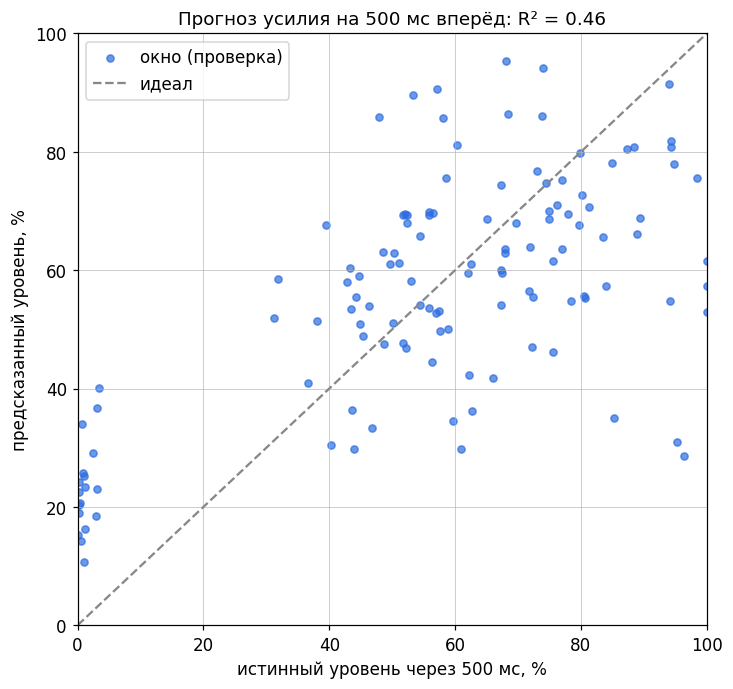

In [9]:
fig, ax = plt.subplots(figsize=(6.8, 6.4))
ax.scatter(true, predicted, s=22, alpha=0.7, color="#2d6cdf", label="окно (проверка)")
ax.plot([0, 100], [0, 100], "--", color="#888", lw=1.5, label="идеал")
ax.set(xlabel="истинный уровень через %.0f мс, %%" % HORIZON,
       ylabel="предсказанный уровень, %",
       xlim=(0, 100), ylim=(0, 100),
       title="Прогноз усилия на %.0f мс вперёд: R² = %.2f" % (HORIZON, r2))
ax.legend()
fig.tight_layout()
plt.show()

Точки у краёв обычно «тянет к середине» — свойство линейной регрессии со
штрафом, а не сбой. Самые дальние от диагонали точки — моменты, когда усилие
резко менялось: именно их правило «будет как сейчас» и не угадывает.

## Задания

1. Приведи R² модели и R² правила «будет как сейчас» для своего варианта.
   Приложи scatter. Выигрывает ли модель, и на сколько?
2. Прогони `HORIZON` = 100, 300, 600, 1000 мс. Построй обе кривые R² от
   горизонта на одном графике. На каком горизонте модель перестаёт обыгрывать
   соперника и почему?
3. Прогони `ALPHA` = 0.01, 1, 100, 10000 при `HORIZON = 500`. Объясни оба
   конца кривой R².